# Hierarchical log–log

Panel from `generate_mock_data(..., hierarchy_levels=...)`. Compare **`LogLogDemandModel()`** (independent SKU effects) vs **`LogLogDemandModel(panel_columns=PanelColumns(group_columns=...))`** (partial pooling).

From the repository root:

```bash
uv sync
```

MCMC settings in these notebooks use small `draws` / `tune` / `chains` for quick runs. Increase them for production-quality inference.


,sku,category_1,category_2
0,sku_1,h1_0,h2_0
240,sku_7,h1_0,h2_0
40,sku_2,h1_0,h2_1
280,sku_8,h1_0,h2_1
80,sku_3,h1_1,h2_2
320,sku_9,h1_1,h2_2
360,sku_10,h1_1,h2_3
120,sku_4,h1_1,h2_3
400,sku_11,h1_2,h2_4
160,sku_5,h1_2,h2_4


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 250 tune and 250 draw iterations (500 + 500 draws total) took 4 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_alpha, sigma_alpha_group_0, eta_alpha_group_0, sigma_alpha_group_1, eta_alpha_group_1, sigma_alpha_sku, eta_alpha_sku, mu_elasticity, sigma_elasticity_group_0, eta_elasticity_group_0, sigma_elasticity_group_1, eta_elasticity_group_1, sigma_elasticity_sku, eta_elasticity_sku, sigma, beta_control]
Sampling 2 chains for 250 tune and 250 draw iterations (500 + 500 draws total) took 11 seconds.



--- Flat model: elasticity_sku (first 8 rows) ---


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
elasticity_sku[0],-0.602,0.320,-1.265,-0.075,0.017,0.011,349.0,375.0,1.00
elasticity_sku[1],-0.806,0.431,-1.636,-0.071,0.022,0.026,384.0,302.0,1.01
elasticity_sku[2],0.120,0.374,-0.558,0.825,0.020,0.016,353.0,323.0,1.01
elasticity_sku[3],-0.518,0.394,-1.235,0.213,0.020,0.014,382.0,334.0,1.00
elasticity_sku[4],-0.847,0.479,-1.817,-0.058,0.025,0.018,363.0,415.0,1.00
elasticity_sku[5],-0.386,0.652,-1.494,0.943,0.026,0.025,631.0,442.0,1.00
elasticity_sku[6],1.373,0.483,0.462,2.191,0.027,0.024,335.0,282.0,1.01
elasticity_sku[7],-0.634,0.308,-1.269,-0.109,0.015,0.013,460.0,422.0,1.00



--- Hierarchical: mu_elasticity + elasticity_sku ---


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_elasticity,-0.409,0.440,-1.230,0.371,0.037,0.031,147.0,120.0,1.01
elasticity_sku[0],-0.726,0.239,-1.140,-0.235,0.011,0.009,461.0,409.0,1.01
elasticity_sku[1],-0.049,0.317,-0.662,0.516,0.018,0.015,330.0,241.0,1.00
elasticity_sku[2],-0.273,0.274,-0.752,0.184,0.017,0.009,268.0,384.0,1.00
elasticity_sku[3],-0.332,0.323,-0.859,0.352,0.017,0.013,373.0,354.0,1.01
elasticity_sku[4],-0.803,0.254,-1.420,-0.411,0.016,0.012,263.0,178.0,1.02
elasticity_sku[5],0.187,0.273,-0.329,0.701,0.012,0.014,472.0,358.0,1.01
elasticity_sku[6],0.215,0.256,-0.197,0.681,0.016,0.018,285.0,393.0,1.00
elasticity_sku[7],-0.502,0.271,-1.009,0.020,0.016,0.012,288.0,149.0,1.00
elasticity_sku[8],-0.398,0.334,-0.987,0.160,0.023,0.016,207.0,262.0,1.01


,sku,elasticity_mean_flat,elasticity_mean_hierarchical
0,sku_1,-0.602191,-0.725819
1,sku_10,-0.805534,-0.049255
2,sku_11,0.120127,-0.273113
3,sku_12,-0.518483,-0.332219
4,sku_2,-0.846977,-0.803004
5,sku_3,-0.385944,0.186777
6,sku_4,1.372582,0.215416
7,sku_5,-0.633835,-0.502099
8,sku_6,0.132060,-0.398322
9,sku_7,-0.801448,-0.652129


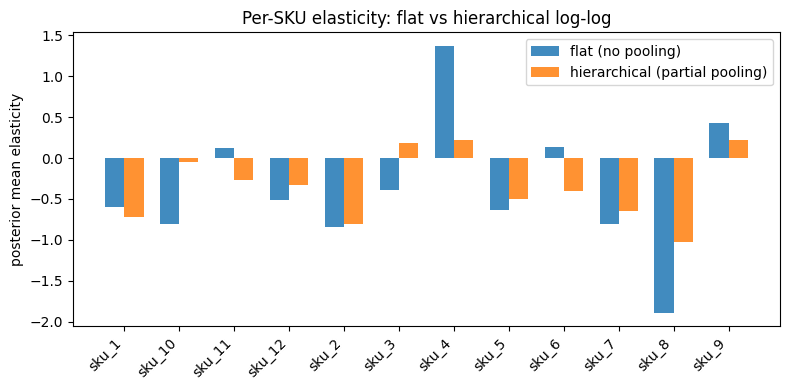

In [3]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import display

from pypricing import PanelColumns, generate_mock_data, LogLogDemandModel

RNG = 42
df = generate_mock_data(
    n_periods=40,
    n_skus=12,
    hierarchy_levels=(3, 2),
    n_controls=1,
    random_state=RNG,
    shape="log_log",
)
display(
    df[["sku", "category_1", "category_2"]]
    .drop_duplicates()
    .sort_values(["category_1", "category_2", "sku"])
)

sample_kw = dict(
    draws=250,
    tune=250,
    chains=2,
    random_seed=RNG,
    progressbar=False,
    compute_convergence_checks=False,
)

model_flat = LogLogDemandModel()
idata_flat = model_flat.fit(df, **sample_kw)

model_hier = LogLogDemandModel(
    panel_columns=PanelColumns(group_columns=("category_1", "category_2"))
)
idata_hier = model_hier.fit(df, **sample_kw)

print("\n--- Flat model: elasticity_sku (first 8 rows) ---")
display(az.summary(idata_flat, var_names=["elasticity_sku"]).head(8))

print("\n--- Hierarchical: mu_elasticity + elasticity_sku ---")
display(az.summary(idata_hier, var_names=["mu_elasticity", "elasticity_sku"]).head(12))

sku_order = model_flat.sku_levels_
flat_mean = idata_flat.posterior["elasticity_sku"].mean(dim=("chain", "draw")).values
hier_mean = idata_hier.posterior["elasticity_sku"].mean(dim=("chain", "draw")).values

cmp = pd.DataFrame(
    {
        "sku": sku_order.astype(str),
        "elasticity_mean_flat": flat_mean,
        "elasticity_mean_hierarchical": hier_mean,
    }
)
display(cmp)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(sku_order))
w = 0.35
ax.bar(x - w / 2, flat_mean, width=w, label="flat (no pooling)", alpha=0.85)
ax.bar(
    x + w / 2, hier_mean, width=w, label="hierarchical (partial pooling)", alpha=0.85
)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in sku_order], rotation=45, ha="right")
ax.set_ylabel("posterior mean elasticity")
ax.legend()
ax.set_title("Per-SKU elasticity: flat vs hierarchical log-log")
plt.tight_layout()
plt.show()

In [4]:
tt_kw = dict(
    test_size=0.25,
    period_col="period",
    draws=250,
    tune=250,
    chains=2,
    random_seed=RNG,
    progressbar=False,
    compute_convergence_checks=False,
)
out_flat = LogLogDemandModel().fit_train_test(df, **tt_kw)
out_hier = LogLogDemandModel(
    panel_columns=PanelColumns(group_columns=("category_1", "category_2"))
).fit_train_test(df, **tt_kw)
print(
    "Train/test RMSE (quantity):",
    out_flat["rmse"],
    "(flat) |",
    out_hier["rmse"],
    "(hierarchical)",
)
print(
    "HDI coverage on test:",
    out_flat["hdi_coverage"],
    "(flat) |",
    out_hier["hdi_coverage"],
    "(hierarchical)",
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 250 tune and 250 draw iterations (500 + 500 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_alpha, sigma_alpha_group_0, eta_alpha_group_0, sigma_alpha_group_1, eta_alpha_group_1, sigma_alpha_sku, eta_alpha_sku, mu_elasticity, sigma_elasticity_group_0, eta_elasticity_group_0, sigma_elasticity_group_1, eta_elasticity_group_1, sigma_elasticity_sku, eta_elasticity_sku, sigma, beta_control]
Sampling 2 chains for 250 tune and 250 draw iterations (500 + 500 draws total) took 12 seconds.


Train/test RMSE (quantity): 23.564536439931228 (flat) | 24.467379131680175 (hierarchical)
HDI coverage on test: 0.9083333333333333 (flat) | 0.9 (hierarchical)
